# Robust Sentiment Classification with RoBERTa - SST-5

This project fine-tunes the pretrained `roberta-base` model for five-class sentiment classification using the Stanford Sentiment Treebank (SST-5). The workflow keeps the official test split untouched, creates a stratified validation split from the training data, selects the best checkpoint using validation macro F1, and evaluates the final model with class-level, ordinal, confidence, and error analysis. A separate masked-language-model demonstration shows a capability of pretrained RoBERTa outside the downstream classification task.

## 1. Import Required Libraries

Import the libraries required for dataset loading, tokenization, RoBERTa fine-tuning, evaluation, visualization, and reproducibility.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Load the SST-5 Dataset

Load SST-5 and inspect the available splits before constructing the modelling data.

In [2]:
dataset = load_dataset("SetFit/sst5")

print(dataset)

for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])} samples")

class_names = [
    "Very Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Very Positive"
]

print("Classes:", class_names)

README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/171k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})
train: 8544 samples
validation: 1101 samples
test: 2210 samples
Classes: ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']


## 3. Create Stratified Train, Validation, and Test Splits

Keep the original test set untouched for final evaluation. Split the training data into training and validation subsets using stratification so the sentiment proportions are preserved.

In [3]:
train_texts = np.array(
    dataset["train"]["text"],
    dtype=object
)
train_labels = np.array(
    dataset["train"]["label"],
    dtype=np.int64
)

test_texts = np.array(
    dataset["test"]["text"],
    dtype=object
)
test_labels = np.array(
    dataset["test"]["label"],
    dtype=np.int64
)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

print("\nTraining Distribution:")
print(np.bincount(train_labels, minlength=5))

print("\nValidation Distribution:")
print(np.bincount(val_labels, minlength=5))

print("\nTest Distribution:")
print(np.bincount(test_labels, minlength=5))

Training Samples: 7689
Validation Samples: 855
Test Samples: 2210

Training Distribution:
[ 983 1996 1461 2090 1159]

Validation Distribution:
[109 222 163 232 129]

Test Distribution:
[279 633 389 510 399]


## 4. Explore the Dataset

Inspect the sentiment distribution and representative examples to understand the structure of the five-class task.

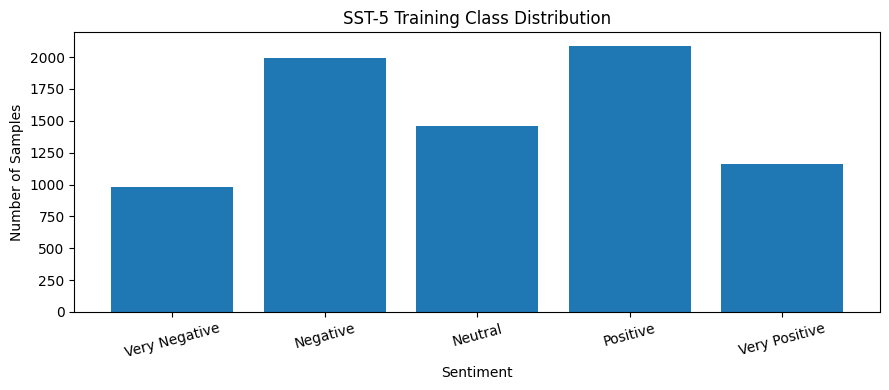

Class: Very Negative
we do n't get paid enough to sit through crap like this .
it is dark , brooding and slow , and takes its central idea way too seriously .

Class: Negative
a moving picture that does not move .
ignore the reputation , and ignore the film .

Class: Neutral
this sort of cute and cloying material is far from zhang 's forte and it shows .
and that should tell you everything you need to know about all the queen 's men .

Class: Positive
this fascinating experiment plays as more of a poetic than a strict reality , creating an intriguing species of artifice that gives the lady and the duke something of a theatrical air .
what lifts the film high above run-of-the-filth gangster flicks is its refusal to recognise any of the signposts , as if discovering a way through to the bitter end without a map .

Class: Very Positive
audiard successfully maintains suspense on different levels throughout a film that is both gripping and compelling .
about schmidt is undoubtedly one of th

In [4]:
train_counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

plt.figure(figsize=(9, 4))
plt.bar(class_names, train_counts)
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.title("SST-5 Training Class Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for class_id, class_name in enumerate(class_names):
    indices = np.where(train_labels == class_id)[0]
    print("=" * 90)
    print("Class:", class_name)
    for index in indices[:2]:
        print(train_texts[index])
    print()

## 5. Load the RoBERTa Tokenizer

Use the pretrained RoBERTa tokenizer so the text is represented using the same subword vocabulary used during pretraining.

In [5]:
model_name = "roberta-base"
max_length = 128

tokenizer = RobertaTokenizerFast.from_pretrained(
    model_name
)

print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)
print("Maximum Sequence Length:", max_length)

sample = tokenizer(
    train_texts[0],
    truncation=True,
    max_length=max_length
)

print("Sample Token Count:", len(sample["input_ids"]))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model: roberta-base
Vocabulary Size: 50265
Maximum Sequence Length: 128
Sample Token Count: 47


## 6. Create Tokenized Datasets

Tokenize the three splits once and create lightweight PyTorch dataset objects. The model receives only token IDs, attention masks, and labels.

In [6]:
class SST5Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = list(texts)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.encodings = tokenizer(
            self.texts,
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "input_ids": torch.tensor(
                self.encodings["input_ids"][index],
                dtype=torch.long
            ),
            "attention_mask": torch.tensor(
                self.encodings["attention_mask"][index],
                dtype=torch.long
            ),
            "labels": torch.tensor(
                self.labels[index],
                dtype=torch.long
            )
        }

train_dataset = SST5Dataset(
    train_texts,
    train_labels,
    tokenizer,
    max_length
)

val_dataset = SST5Dataset(
    val_texts,
    val_labels,
    tokenizer,
    max_length
)

test_dataset = SST5Dataset(
    test_texts,
    test_labels,
    tokenizer,
    max_length
)

print("Training Dataset:", len(train_dataset))
print("Validation Dataset:", len(val_dataset))
print("Test Dataset:", len(test_dataset))
print("Sample Keys:", train_dataset[0].keys())
print("Input Shape:", train_dataset[0]["input_ids"].shape)

Training Dataset: 7689
Validation Dataset: 855
Test Dataset: 2210
Sample Keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
Input Shape: torch.Size([128])


## 7. Build the RoBERTa Classifier

Load pretrained RoBERTa and attach a five-class sequence-classification head. The Transformer backbone starts from pretrained language representations, while the classification head is initialized for SST-5.

In [7]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={
        i: name
        for i, name in enumerate(class_names)
    },
    label2id={
        name: i
        for i, name in enumerate(class_names)
    }
)

model.to(device)

print("Model:", model_name)
print("Number of Labels:", model.config.num_labels)
print(
    "Trainable Parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of Labels: 5
Trainable Parameters: 124,649,477


## 8. Configure Fine-Tuning

Use a conservative fine-tuning setup for RoBERTa. Validation macro F1 is used for checkpoint selection because the task is imbalanced and all sentiment classes should contribute to model selection.

In [8]:
batch_size = 16
learning_rate = 2e-5
num_epochs = 4
weight_decay = 0.01
warmup_ratio = 0.10

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

total_training_steps = len(train_loader) * num_epochs
warmup_steps = int(total_training_steps * warmup_ratio)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

criterion = torch.nn.CrossEntropyLoss()

print("Batch Size:", batch_size)
print("Learning Rate:", learning_rate)
print("Epochs:", num_epochs)
print("Weight Decay:", weight_decay)
print("Warmup Steps:", warmup_steps)
print("Total Training Steps:", total_training_steps)

Batch Size: 16
Learning Rate: 2e-05
Epochs: 4
Weight Decay: 0.01
Warmup Steps: 192
Total Training Steps: 1924


## 9. Define Evaluation Functions

Compute accuracy, macro and weighted metrics, and retain the logits needed for later confidence and ordinal analysis.

In [9]:
def evaluate_model(model, data_loader):
    model.eval()

    all_logits = []
    all_labels = []

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(
                outputs.logits,
                labels
            )

            batch_size_actual = labels.size(0)
            total_loss += loss.item() * batch_size_actual
            total_examples += batch_size_actual

            all_logits.append(
                outputs.logits.detach().cpu()
            )
            all_labels.append(
                labels.detach().cpu()
            )

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    predictions = np.argmax(logits, axis=1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "loss": total_loss / total_examples,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "logits": logits,
        "labels": labels,
        "predictions": predictions
    }

## 10. Fine-Tune RoBERTa

Train on the training split only, evaluate on the validation split after every epoch, and retain the checkpoint with the strongest validation macro F1.

In [10]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": []
}

best_val_f1 = -np.inf
best_state = None
best_epoch = None
patience = 2
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    total_examples = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        batch_size_actual = labels.size(0)
        running_loss += loss.item() * batch_size_actual
        total_examples += batch_size_actual

    train_loss = running_loss / total_examples

    val_results = evaluate_model(
        model,
        val_loader
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_results["loss"])
    history["val_accuracy"].append(val_results["accuracy"])
    history["val_macro_f1"].append(val_results["macro_f1"])

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_results['loss']:.4f} | "
        f"Val Accuracy: {val_results['accuracy']:.4f} | "
        f"Val Macro F1: {val_results['macro_f1']:.4f}"
    )

    if val_results["macro_f1"] > best_val_f1:
        best_val_f1 = val_results["macro_f1"]
        best_epoch = epoch + 1
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(
            f"Early stopping after epoch {epoch + 1}."
        )
        break

if best_state is not None:
    model.load_state_dict(best_state)

model.to(device)

print("Best Epoch:", best_epoch)
print(f"Best Validation Macro F1: {best_val_f1:.4f}")

Epoch 1/4 | Train Loss: 1.5801 | Val Loss: 1.5731 | Val Accuracy: 0.2713 | Val Macro F1: 0.0854
Epoch 2/4 | Train Loss: 1.5740 | Val Loss: 1.5698 | Val Accuracy: 0.2713 | Val Macro F1: 0.0854
Epoch 3/4 | Train Loss: 1.5730 | Val Loss: 1.5670 | Val Accuracy: 0.2655 | Val Macro F1: 0.1333
Epoch 4/4 | Train Loss: 1.5656 | Val Loss: 1.5643 | Val Accuracy: 0.2854 | Val Macro F1: 0.1656
Best Epoch: 4
Best Validation Macro F1: 0.1656


## 11. Training Curves

Review loss and validation metrics to assess convergence and detect overfitting.

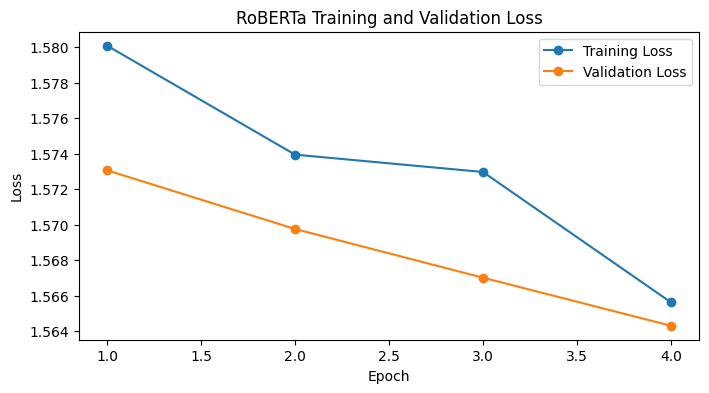

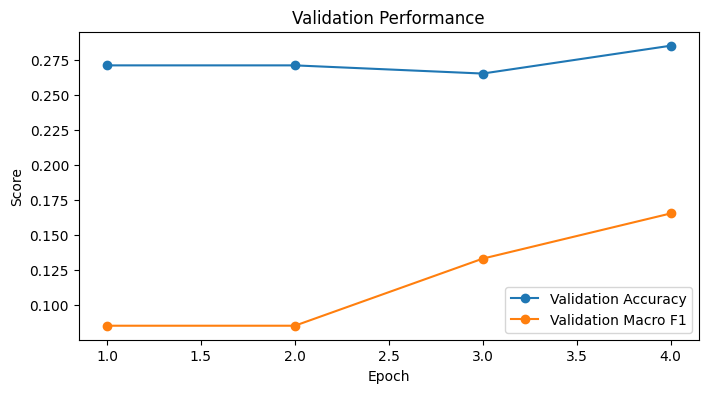

In [11]:
epochs_ran = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_ran,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    epochs_ran,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    epochs_ran,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)
plt.plot(
    epochs_ran,
    history["val_macro_f1"],
    marker="o",
    label="Validation Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")
plt.legend()
plt.show()

## 12. Final Test Evaluation

Evaluate the restored best checkpoint exactly once on the untouched test set and calculate final performance metrics.

In [12]:
test_results = evaluate_model(
    model,
    test_loader
)

test_logits = test_results["logits"]
test_predictions = test_results["predictions"]
test_labels_final = test_results["labels"]

print(f"Test Loss: {test_results['loss']:.4f}")
print(f"Test Accuracy: {test_results['accuracy']:.4f}")
print(f"Test Macro Precision: {test_results['macro_precision']:.4f}")
print(f"Test Macro Recall: {test_results['macro_recall']:.4f}")
print(f"Test Macro F1: {test_results['macro_f1']:.4f}")
print(f"Test Weighted F1: {test_results['weighted_f1']:.4f}")

Test Loss: 1.5703
Test Accuracy: 0.2787
Test Macro Precision: 0.1918
Test Macro Recall: 0.2291
Test Macro F1: 0.1620
Test Weighted F1: 0.1986


## 13. Classification Report and Confusion Matrix

Inspect performance for each sentiment class and identify the directions in which errors occur.

               precision    recall  f1-score   support

Very Negative     0.0000    0.0000    0.0000       279
     Negative     0.3122    0.3191    0.3156       633
      Neutral     0.3871    0.0617    0.1064       389
     Positive     0.2598    0.7647    0.3879       510
Very Positive     0.0000    0.0000    0.0000       399

     accuracy                         0.2787      2210
    macro avg     0.1918    0.2291    0.1620      2210
 weighted avg     0.2175    0.2787    0.1986      2210



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Very Negative,Negative,Neutral,Positive,Very Positive
Very Negative,0,97,5,177,0
Negative,0,202,17,414,0
Neutral,0,140,24,225,0
Positive,0,111,9,390,0
Very Positive,0,97,7,295,0


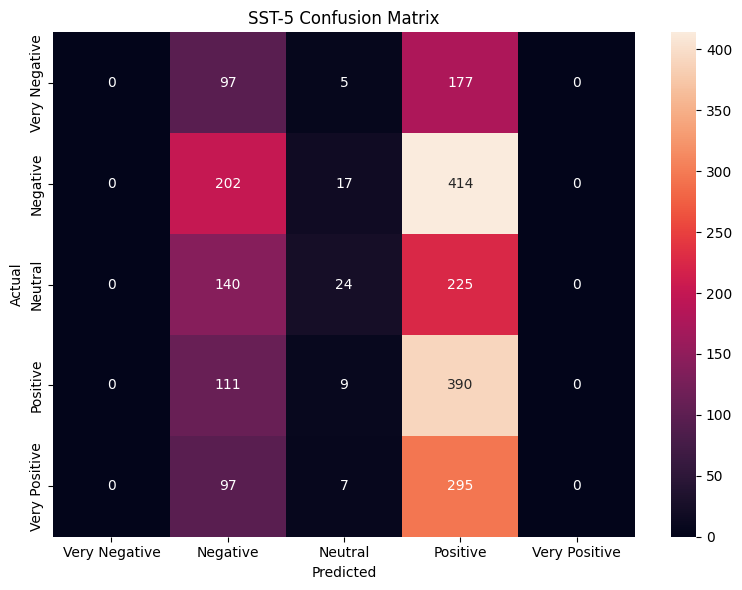

In [13]:
print(
    classification_report(
        test_labels_final,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(
    test_labels_final,
    test_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SST-5 Confusion Matrix")
plt.tight_layout()
plt.show()

## 14. Ordinal Sentiment Error Analysis

SST-5 labels have an ordered sentiment scale. Measure the magnitude of prediction errors rather than treating every incorrect prediction as equally severe.

Mean Absolute Sentiment Error: 1.2122
Exact Sentiment Accuracy: 0.2787
Within One Sentiment Level: 0.6330


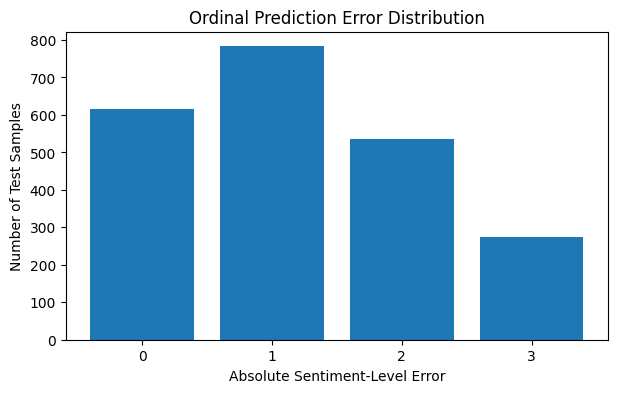

In [14]:
absolute_errors = np.abs(
    test_labels_final - test_predictions
)

mean_absolute_sentiment_error = np.mean(
    absolute_errors
)

exact_accuracy = np.mean(
    absolute_errors == 0
)

within_one_level = np.mean(
    absolute_errors <= 1
)

print(
    f"Mean Absolute Sentiment Error: "
    f"{mean_absolute_sentiment_error:.4f}"
)

print(
    f"Exact Sentiment Accuracy: "
    f"{exact_accuracy:.4f}"
)

print(
    f"Within One Sentiment Level: "
    f"{within_one_level:.4f}"
)

error_counts = (
    pd.Series(absolute_errors)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)
plt.xlabel("Absolute Sentiment-Level Error")
plt.ylabel("Number of Test Samples")
plt.title("Ordinal Prediction Error Distribution")
plt.show()

## 15. Confidence Analysis

Compare prediction confidence for correct and incorrect examples to identify whether the model is appropriately confident around its mistakes.

Mean Confidence - Correct: 0.2832
Mean Confidence - Incorrect: 0.2831


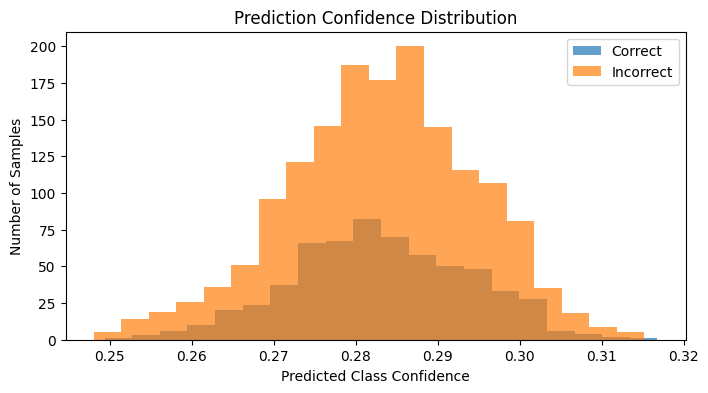

In [15]:
probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=-1
).numpy()

predicted_confidence = probabilities[
    np.arange(len(test_predictions)),
    test_predictions
]

correct_mask = (
    test_predictions == test_labels_final
)

print(
    f"Mean Confidence - Correct: "
    f"{predicted_confidence[correct_mask].mean():.4f}"
)

print(
    f"Mean Confidence - Incorrect: "
    f"{predicted_confidence[~correct_mask].mean():.4f}"
)

plt.figure(figsize=(8, 4))
plt.hist(
    predicted_confidence[correct_mask],
    bins=20,
    alpha=0.7,
    label="Correct"
)
plt.hist(
    predicted_confidence[~correct_mask],
    bins=20,
    alpha=0.7,
    label="Incorrect"
)
plt.xlabel("Predicted Class Confidence")
plt.ylabel("Number of Samples")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()

## 16. Representative Error Analysis

Inspect representative misclassified sentences and their strongest alternative predictions to distinguish close sentiment mistakes from severe reversals.

In [16]:
misclassified_indices = np.where(
    test_predictions != test_labels_final
)[0]

print(
    "Misclassified Test Samples:",
    len(misclassified_indices)
)

for index in misclassified_indices[:10]:
    probabilities_row = probabilities[index]

    top_indices = np.argsort(
        probabilities_row
    )[-3:][::-1]

    print("=" * 100)
    print("Text:", test_texts[index])
    print(
        "True Label:",
        class_names[test_labels_final[index]]
    )
    print(
        "Predicted Label:",
        class_names[test_predictions[index]]
    )
    print("Top Predictions:")

    for class_id in top_indices:
        print(
            f"  {class_names[class_id]}: "
            f"{probabilities_row[class_id]:.4f}"
        )

Misclassified Test Samples: 1594
Text: a gob of drivel so sickly sweet , even the eager consumers of moore 's pasteurized ditties will retch it up like rancid crème brûlée .
True Label: Very Negative
Predicted Label: Positive
Top Predictions:
  Positive: 0.2906
  Negative: 0.2577
  Neutral: 0.1793
Text: ` how many more voyages can this limping but dearly-loved franchise survive ? '
True Label: Neutral
Predicted Label: Positive
Top Predictions:
  Positive: 0.2730
  Negative: 0.2629
  Neutral: 0.1928
Text: so relentlessly wholesome it made me want to swipe something .
True Label: Neutral
Predicted Label: Negative
Top Predictions:
  Negative: 0.2829
  Positive: 0.2513
  Neutral: 0.2147
Text: gangs of new york is an unapologetic mess , whose only saving grace is that it ends by blowing just about everything up .
True Label: Very Negative
Predicted Label: Positive
Top Predictions:
  Positive: 0.2932
  Negative: 0.2527
  Neutral: 0.1758
Text: we never really feel involved with the story , as

## 17. Interactive Sentiment Prediction

Use the fine-tuned RoBERTa classifier on custom text and inspect its predicted sentiment distribution.

In [17]:
def predict_sentiment(text):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    ).cpu().numpy()[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    print("Text:", text)
    print(
        "Prediction:",
        class_names[predicted_class]
    )
    print(
        "Confidence:",
        f"{probabilities[predicted_class]:.4f}"
    )

    print("\nClass Probabilities:")

    for class_name, probability in zip(
        class_names,
        probabilities
    ):
        print(
            f"{class_name:<15}"
            f"{probability:.4f}"
        )

examples = [
    "This is the worst thing ever.",
    "It was okay, nothing special.",
    "I liked it quite a bit.",
    "Absolutely fantastic experience."
]

for example in examples:
    predict_sentiment(example)
    print("=" * 70)

Text: This is the worst thing ever.
Prediction: Negative
Confidence: 0.2857

Class Probabilities:
Very Negative  0.1460
Negative       0.2857
Neutral        0.2756
Positive       0.1881
Very Positive  0.1046
Text: It was okay, nothing special.
Prediction: Negative
Confidence: 0.2694

Class Probabilities:
Very Negative  0.1402
Negative       0.2694
Neutral        0.2491
Positive       0.2121
Very Positive  0.1292
Text: I liked it quite a bit.
Prediction: Negative
Confidence: 0.2751

Class Probabilities:
Very Negative  0.1428
Negative       0.2751
Neutral        0.2685
Positive       0.1993
Very Positive  0.1143
Text: Absolutely fantastic experience.
Prediction: Negative
Confidence: 0.2632

Class Probabilities:
Very Negative  0.1381
Negative       0.2632
Neutral        0.2207
Positive       0.2364
Very Positive  0.1417


## 18. RoBERTa Masked Language Modelling Demonstration

Use the separate pretrained `roberta-base` masked-language model to demonstrate a pretrained language-modelling capability outside the fine-tuned sentiment classifier.

In [18]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model="roberta-base",
    device=0 if torch.cuda.is_available() else -1
)

def suggest_words(text, top_k=5):
    if "<mask>" not in text:
        print("Please include <mask> in your sentence.")
        return

    results = fill_mask(
        text,
        top_k=top_k
    )

    print("Input:", text)
    print("Suggestions:")

    for result in results:
        word = result["token_str"].strip()
        score = result["score"]
        print(f"{word:<20}{score:.4f}")

suggest_words("The movie was <mask>.")
suggest_words("This experience felt <mask> and strange.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Input: The movie was <mask>.
Suggestions:
good                0.1075
awful               0.0763
great               0.0714
terrible            0.0682
released            0.0271
Input: This experience felt <mask> and strange.
Suggestions:
foreign             0.1090
strange             0.0694
unfamiliar          0.0529
surreal             0.0513
unexpected          0.0502


## 19. Key Findings



## 20. Conclusion

